1. Predicting SalePrice

C:\Users\DELL\AppData\Local\Temp\ipykernel_10212\2005528187.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df, x='Importance', y='Feature', palette='viridis', ax=ax)


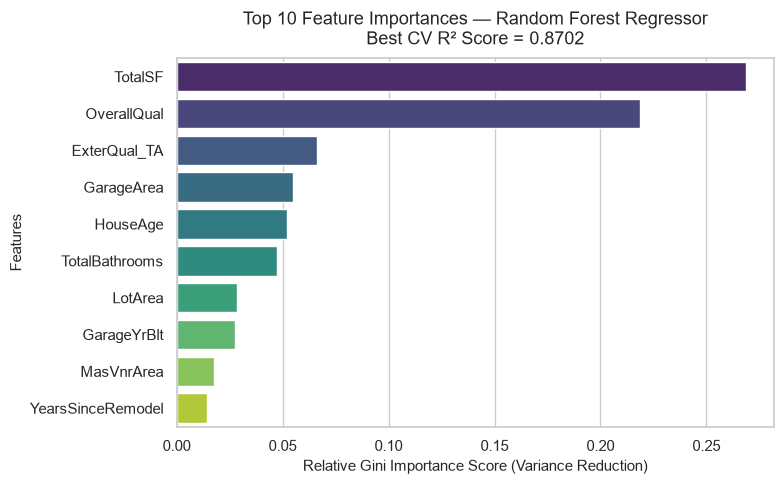

Optimal Parameters: {'max_depth': None, 'max_features': 0.3, 'n_estimators': 100}
Optimal Cross-Validation R2 Score: 0.8702


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Load the preprocessed dataset
df = pd.read_csv('df_EDA_minmax.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['SalePrice', 'Price_Category'], errors='ignore')
y = df['SalePrice']

# 2. Define the structural hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.3]
}

# 3. Setup and execute the 5-Fold Cross Validation Grid Search
rf_regressor = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_regressor, param_grid, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)

# Extract optimized parameters
best_params = grid_search.best_params_
best_r2_score = grid_search.best_score_

# 4. Extract and sort global feature importances from the best model
best_rf = grid_search.best_estimator_
importances = best_rf.feature_importances_
feature_names = X.columns

importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# 5. Generate and Save Top 10 Feature Importance Plot
plt.rc('font', size=11)
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importances_df, x='Importance', y='Feature', palette='viridis', ax=ax)

ax.set_title(f'Top 10 Feature Importances — Random Forest Regressor\nBest CV R² Score = {best_r2_score:.4f}', fontsize=13, pad=10)
ax.set_xlabel('Relative Gini Importance Score (Variance Reduction)', fontsize=11)
ax.set_ylabel('Features', fontsize=11)
plt.tight_layout()

# Save image locally
plt.show()

print(f"Optimal Parameters: {best_params}")
print(f"Optimal Cross-Validation R2 Score: {best_r2_score:.4f}")

In [2]:
print(best_params)
print(best_r2_score)

{'max_depth': None, 'max_features': 0.3, 'n_estimators': 100}
0.8701520580577571


2. Predicting Price_Category

C:\Users\DELL\AppData\Local\Temp\ipykernel_10212\4097246880.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df, x='Importance', y='Feature', palette='magma', ax=ax)


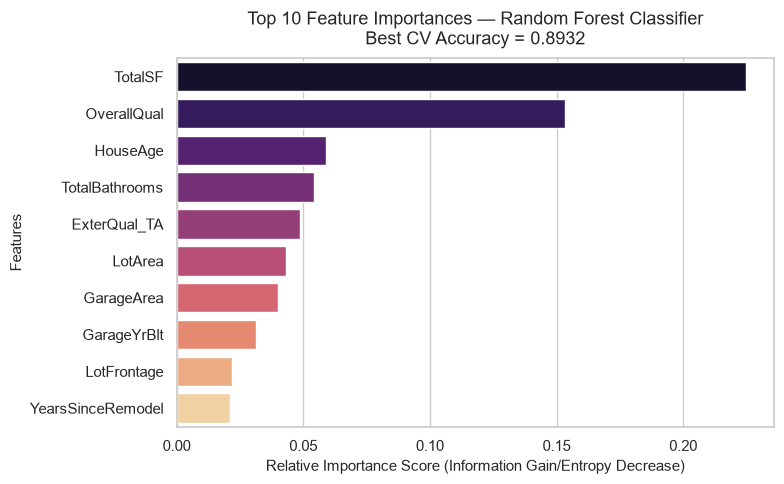

{'criterion': 'entropy', 'max_depth': 20, 'max_features': 0.3, 'n_estimators': 100}
0.8931506849315068
Optimal Classification Parameters: {'criterion': 'entropy', 'max_depth': 20, 'max_features': 0.3, 'n_estimators': 100}
Optimal Cross-Validation Accuracy: 0.8932


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Load the preprocessed dataset
df = pd.read_csv('df_EDA_minmax.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['SalePrice', 'Price_Category'], errors='ignore')
y = df['Price_Category']

# 2. Define the cross-validation parameter tuning space
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.3],
    'criterion': ['gini', 'entropy']
}

# 3. Setup and execute the 5-Fold Cross Validation Grid Search
rf_classifier = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='accuracy', return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)

best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

# 4. Extract and sort global feature importances from the best model
best_rf_clf = grid_search.best_estimator_
importances = best_rf_clf.feature_importances_
feature_names = X.columns

importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# 5. Generate and Save Top 10 Classification Importance Plot
plt.rc('font', size=11)
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importances_df, x='Importance', y='Feature', palette='magma', ax=ax)

ax.set_title(f'Top 10 Feature Importances — Random Forest Classifier\nBest CV Accuracy = {best_accuracy:.4f}', fontsize=13, pad=10)
ax.set_xlabel('Relative Importance Score (Information Gain/Entropy Decrease)', fontsize=11)
ax.set_ylabel('Features', fontsize=11)
plt.tight_layout()

# Save image locally
plt.show()
print(best_params)
print(best_accuracy)

print(f"Optimal Classification Parameters: {best_params}")
print(f"Optimal Cross-Validation Accuracy: {best_accuracy:.4f}")